# 01 - Analyse Exploratoire des Données (EDA)
## BTC Multivariate Forecast
### Étudiant A - Phase 1

In [1]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Import des modules personnalisés
import sys
sys.path.append('..')
from src.data.collector import DataCollector
from src.data.preprocessor import DataPreprocessor
from src.visualization.plots import Visualizer

# Configuration
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
# Chargement du dataset fusionné
df = pd.read_csv('../data/processed/merged_dataset.csv', index_col=0, parse_dates=True)
# Nettoyage  des noms de colonnes 
rename_map = { "BTC_('Close', 'BTC-USD')": "BTC_Close", "BTC_('Volume', 'BTC-USD')": "BTC_Volume", "ETH_('Close', 'ETH-USD')": "ETH_Close", "ETH_('Volume', 'ETH-USD')": "ETH_Volume", "BNB_('Close', 'BNB-USD')": "BNB_Close", "BNB_('Volume', 'BNB-USD')": "BNB_Volume", "SP500_('Close', '^GSPC')": "SP500_Close", "SP500_('Volume', '^GSPC')": "SP500_Volume", "DXY_('Close', 'DX-Y.NYB')": "DXY_Close", "DXY_('Volume', 'DX-Y.NYB')": "DXY_Volume", } 
df.rename(columns=rename_map, inplace=True)

print(f"Shape: {df.shape}")
print(f"Période: {df.index[0]} à {df.index[-1]}")
print(f"Variables: {df.columns.tolist()}")

Shape: (1258, 10)
Période: 2020-01-02 00:00:00 à 2024-12-31 00:00:00
Variables: ['BTC_Close', 'BTC_Volume', 'ETH_Close', 'ETH_Volume', 'BNB_Close', 'BNB_Volume', 'SP500_Close', 'SP500_Volume', 'DXY_Close', 'DXY_Volume']


## 1. Aperçu général des données

In [31]:
# Premières lignes
df.head()

,BTC_Close,BTC_Volume,ETH_Close,ETH_Volume,BNB_Close,BNB_Volume,SP500_Close,SP500_Volume,DXY_Close,DXY_Volume
Date,,,,,,,,,,
2020-01-02,6985.4702,20802083465,127.4102,8032709256,13.0270,156376427,3257.8501,3459930000,96.8500,0
2020-01-03,7344.8843,28111481032,134.1717,10476845358,13.6605,173683857,3234.8501,3484700000,96.8400,0
2020-01-06,7769.2192,23276261598,144.3042,9093747121,14.9578,224800409,3246.2800,3702460000,96.6700,0
2020-01-07,8163.6924,28767291327,143.5440,9257954672,15.0092,191948560,3237.1799,3435910000,96.9800,0
2020-01-08,8079.8628,31672559265,141.2581,9387194957,14.6029,183632222,3253.0500,3726840000,97.3000,0


In [32]:
# Dernières lignes
df.tail()

,BTC_Close,BTC_Volume,ETH_Close,ETH_Volume,BNB_Close,BNB_Volume,SP500_Close,SP500_Volume,DXY_Close,DXY_Volume
Date,,,,,,,,,,
2024-12-24,98676.0938,47114953674,3492.0498,23083678195,696.7411,1145844254,6040.0400,1757720000,108.2600,0
2024-12-26,95795.5156,47054980873,3331.2258,22247726776,688.3601,1253518341,6037.5898,2904530000,108.1300,0
2024-12-27,94164.8594,52419934565,3328.9170,24091627403,690.4294,1884726979,5970.8398,3159610000,108.0000,0
2024-12-30,92643.2109,56188003691,3356.3926,26981583962,704.1463,1790325219,5906.9399,3433250000,108.1300,0
2024-12-31,93429.2031,43625106843,3332.5317,20845452085,700.9869,2372886701,5881.6299,3128350000,108.4900,0


In [33]:
# Informations générales
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   BTC_Close     1258 non-null   float64
 1   BTC_Volume    1258 non-null   int64  
 2   ETH_Close     1258 non-null   float64
 3   ETH_Volume    1258 non-null   int64  
 4   BNB_Close     1258 non-null   float64
 5   BNB_Volume    1258 non-null   int64  
 6   SP500_Close   1258 non-null   float64
 7   SP500_Volume  1258 non-null   int64  
 8   DXY_Close     1258 non-null   float64
 9   DXY_Volume    1258 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 108.1 KB


In [34]:
# Statistiques descriptives
df.describe()

,BTC_Close,BTC_Volume,ETH_Close,ETH_Volume,BNB_Close,BNB_Volume,SP500_Close,SP500_Volume,DXY_Close,DXY_Volume
count,1258.0000,1258.0000,1258.0000,1258.0000,1258.0000,1258.0000,1258.0000,1258.0000,1258.0000,1258.0000
mean,36334.0706,36289152155.7448,1983.2547,18046673543.4817,307.1110,1528315370.2870,4259.6069,4376286875.9936,99.9909,0.0000
std,21095.9080,20545152107.5042,1147.0571,10945095685.4089,196.0157,1498623650.4383,767.4486,1052113468.2682,5.7696,0.0000
min,4970.7881,9392909295.0000,110.6059,3353025102.0000,9.3861,136599245.0000,2237.3999,0.0000,89.4400,0.0000
25%,19644.6797,24322705742.0000,1254.0220,10869879999.0000,214.4991,481191743.7500,3819.0526,3751010000.0000,94.1450,0.0000
50%,32211.8994,32353434851.5000,1869.3257,15994810280.5000,300.9130,1141625397.0000,4204.8801,4113210000.0000,101.5300,0.0000
75%,50771.3916,42744922088.2500,2894.4245,21917333593.5000,446.2464,2005454170.5000,4603.8901,4712907500.0000,104.3200,0.0000
max,106140.6016,350967941479.0000,4812.0874,84482912776.0000,739.2527,17982945189.0000,6090.2700,9976520000.0000,114.1100,0.0000


In [35]:
# Vérification des valeurs manquantes
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

## 2. Visualisation des séries temporelles

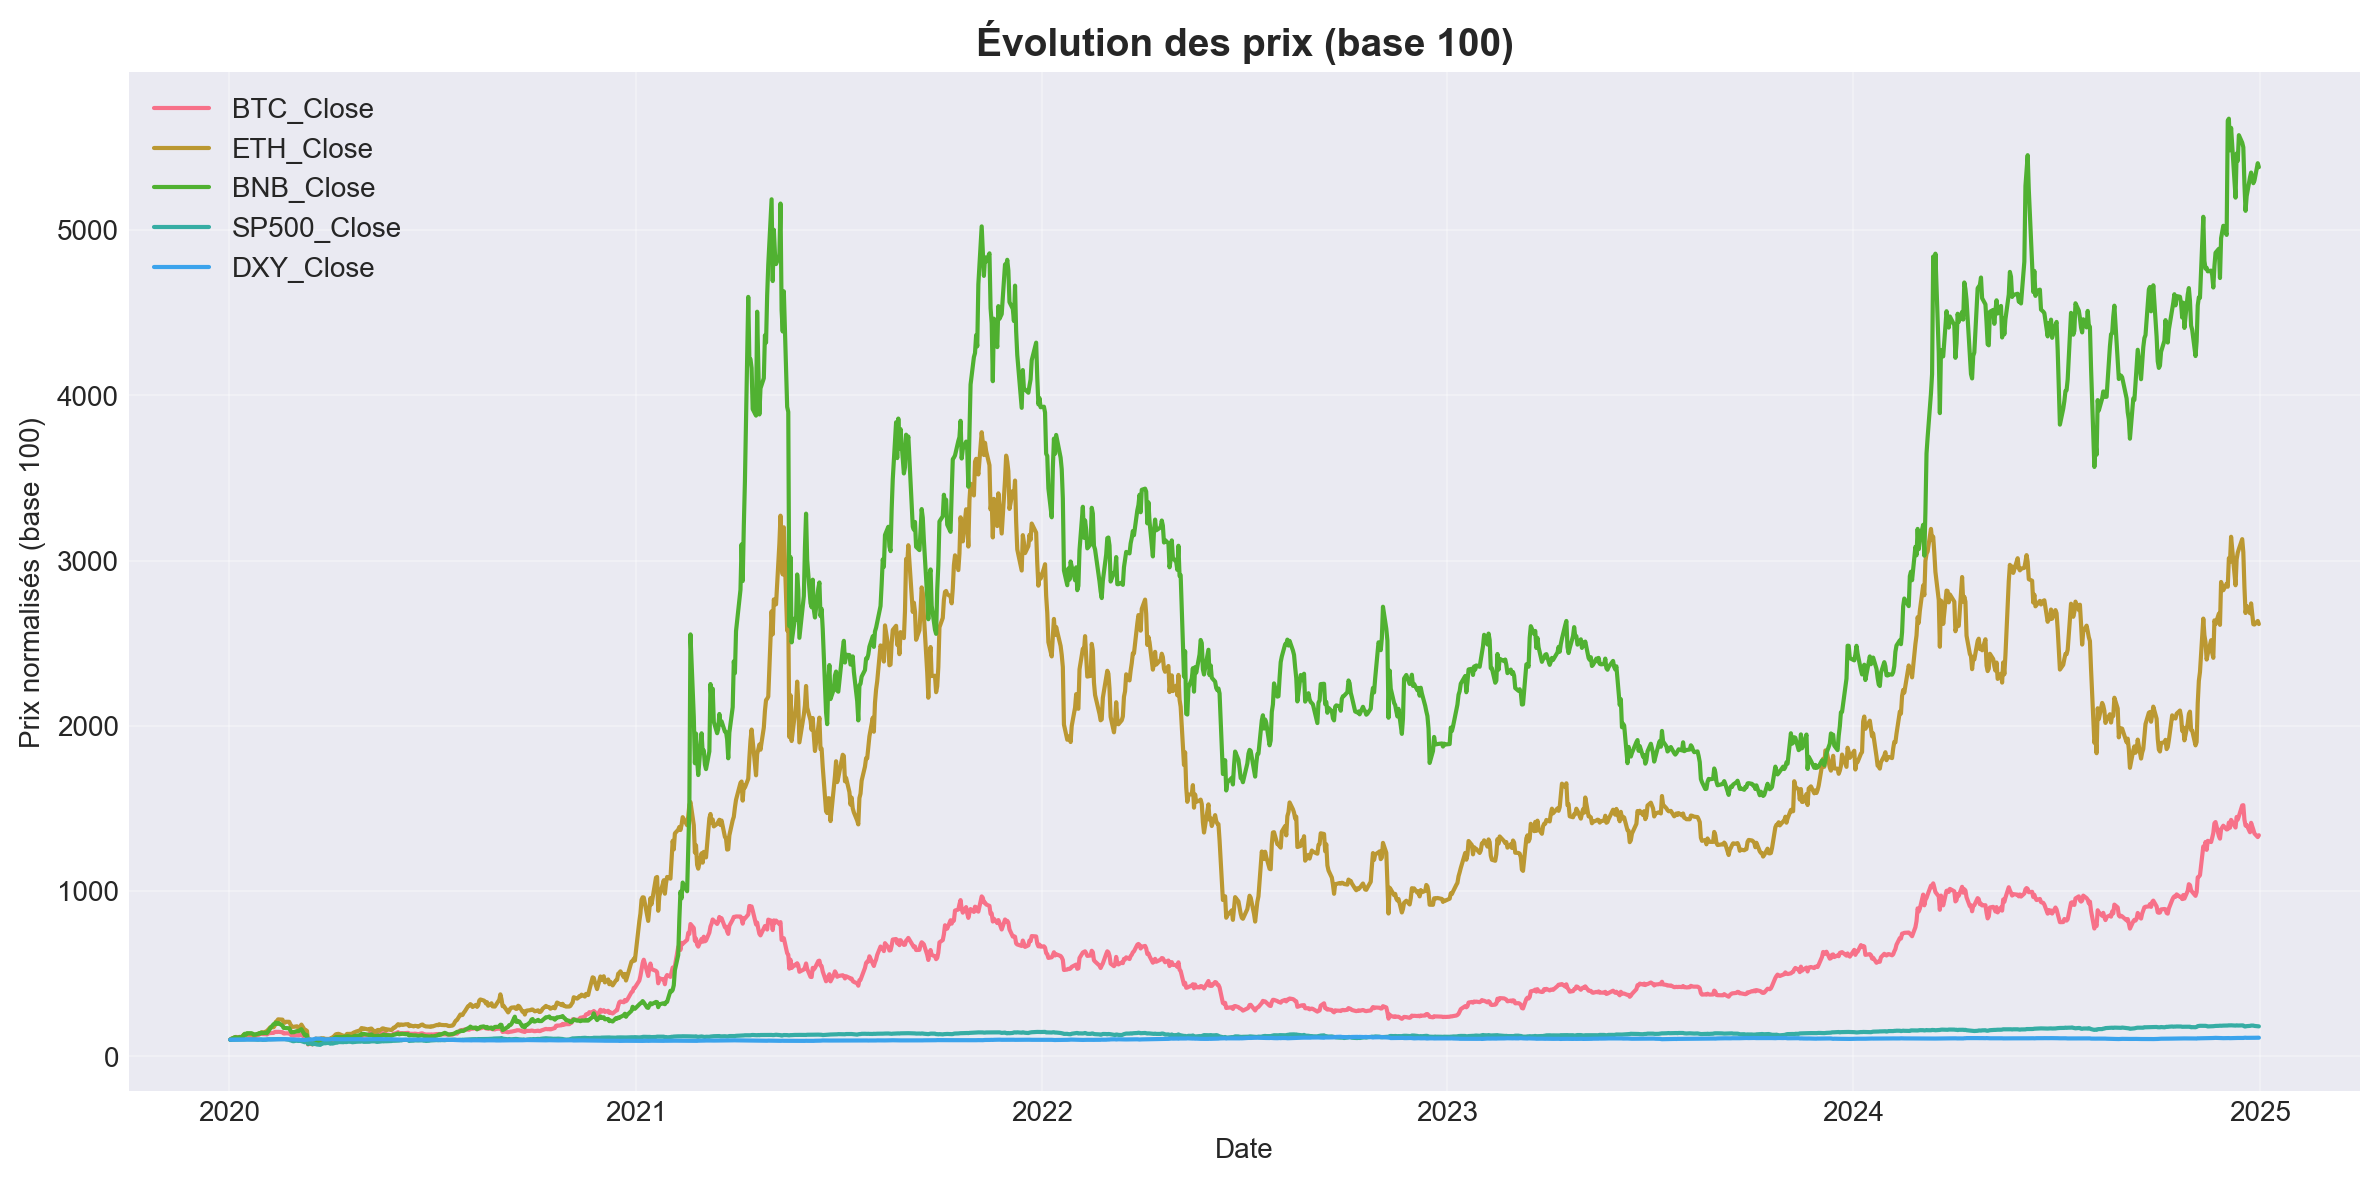

In [36]:
# Initialisation du visualiseur
viz = Visualizer()

# Prix normalisés (base 100)
viz.plot_prices(df, title="Évolution des prix (base 100)")

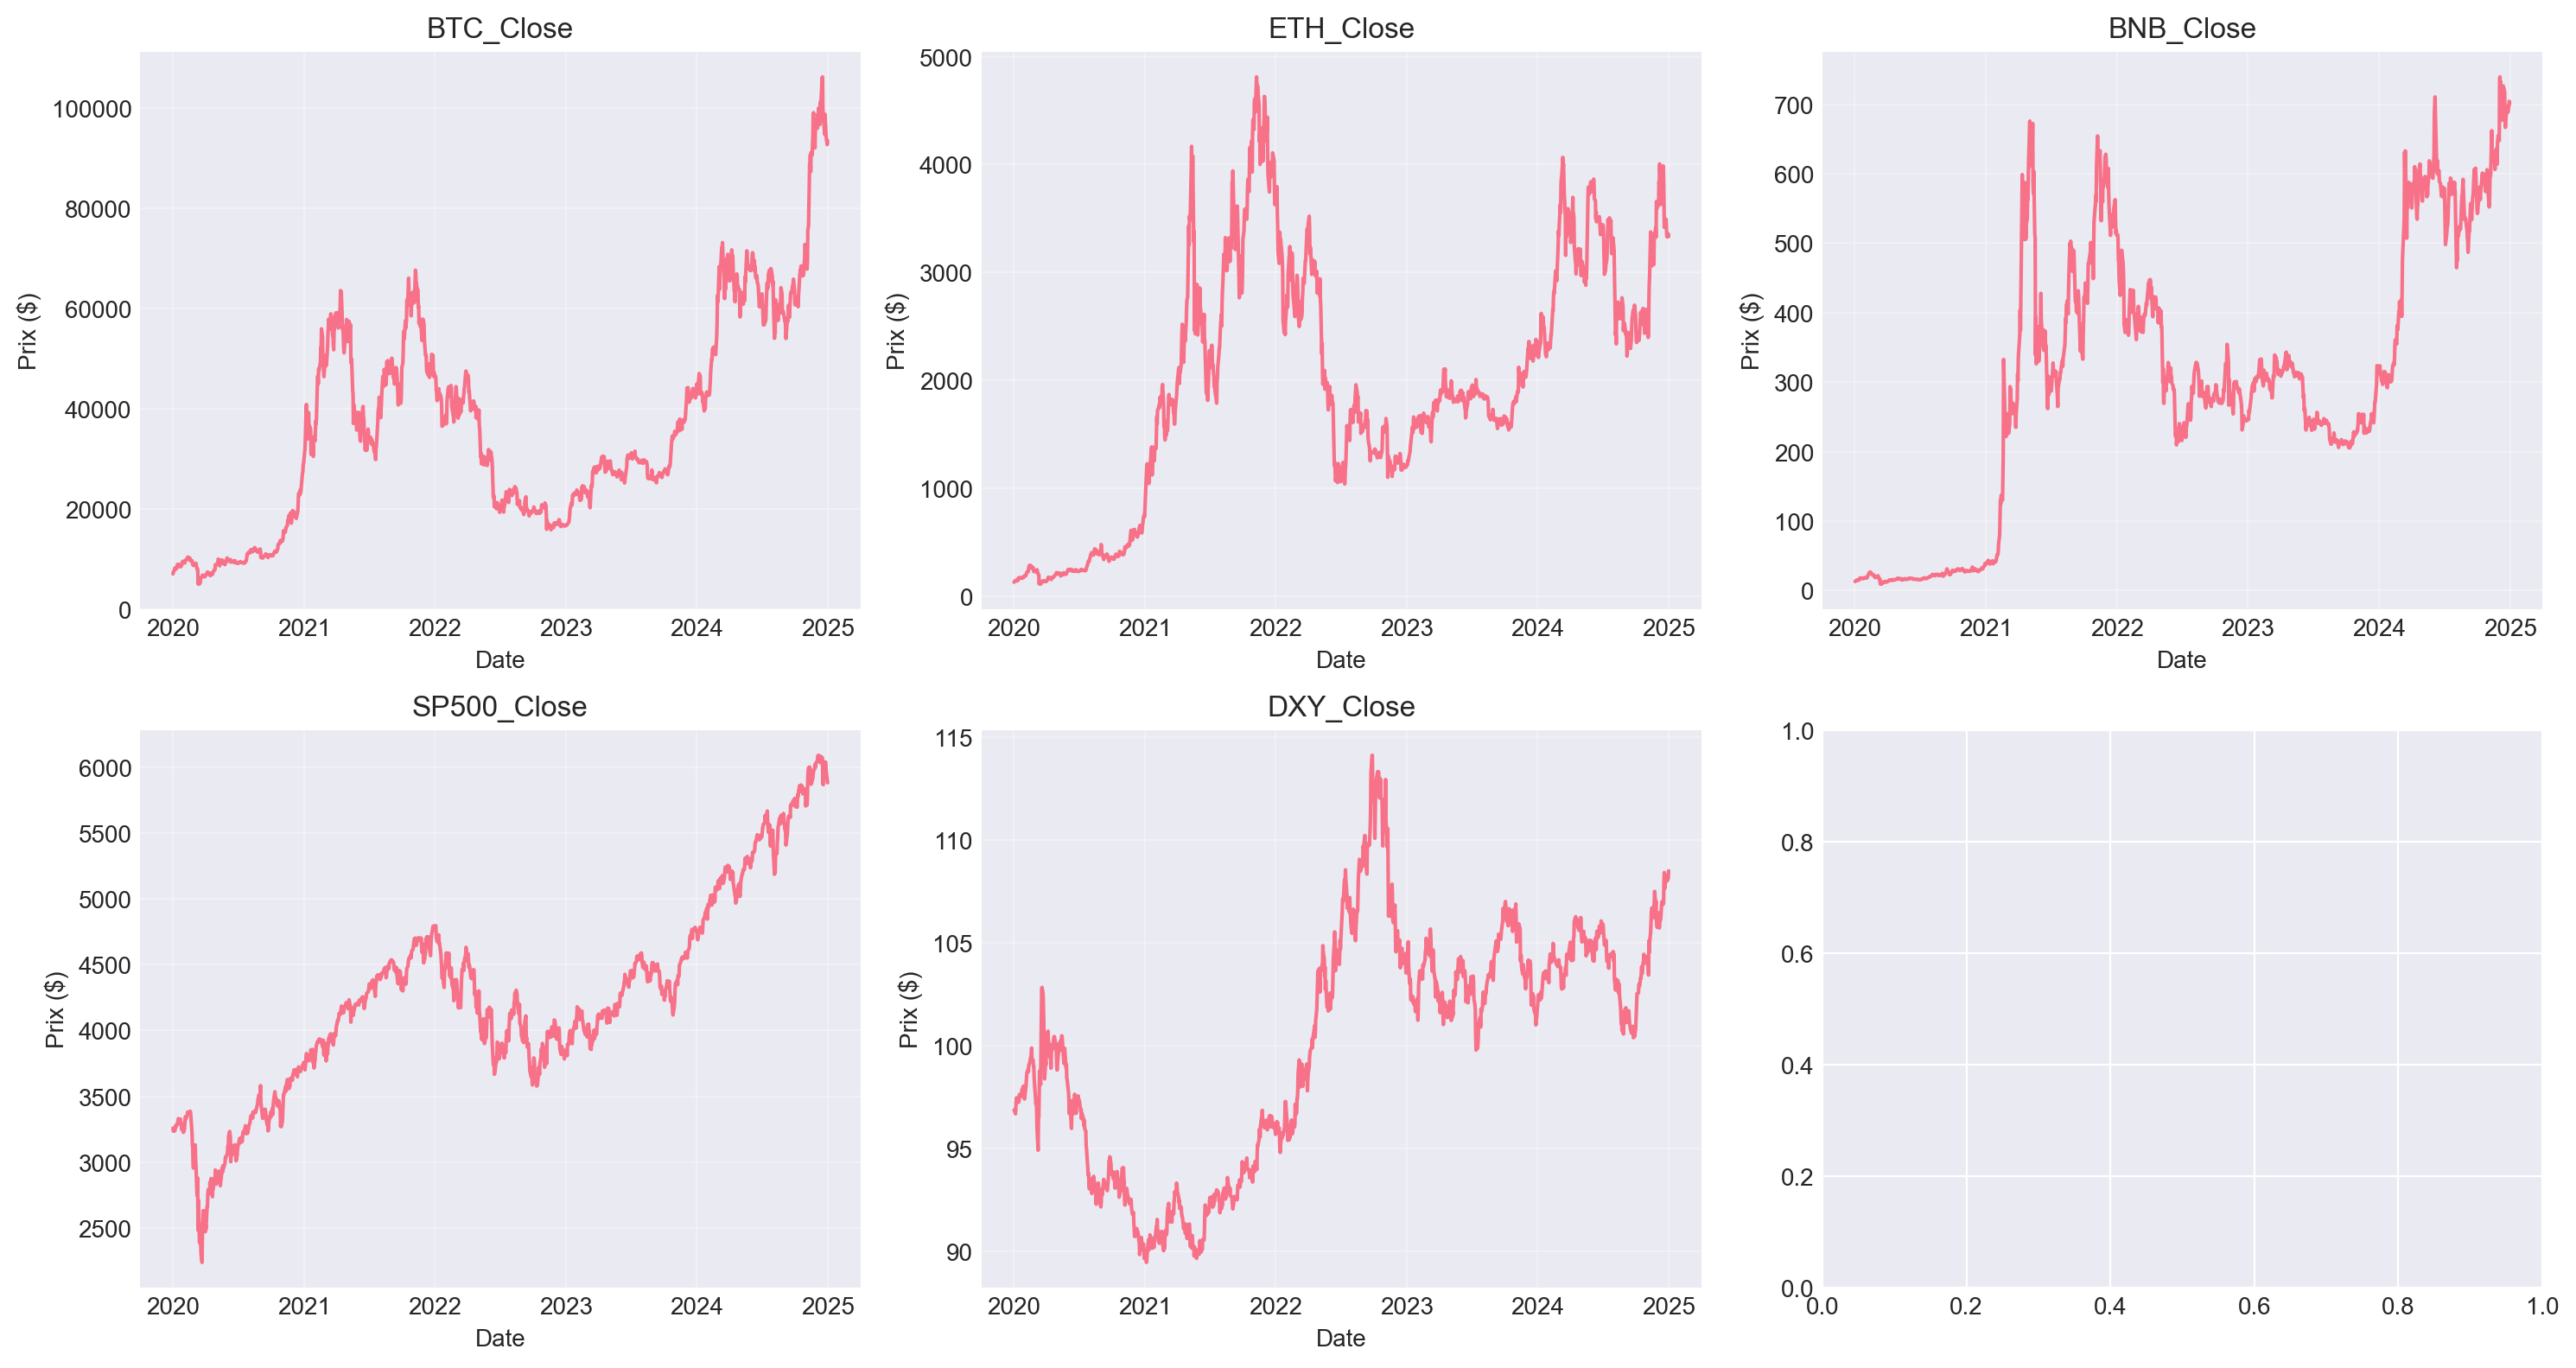

In [37]:
# Prix individuels
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

price_cols = [col for col in df.columns if 'Close' in col]
for i, col in enumerate(price_cols):
    axes[i].plot(df.index, df[col])
    axes[i].set_title(col)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Prix ($)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

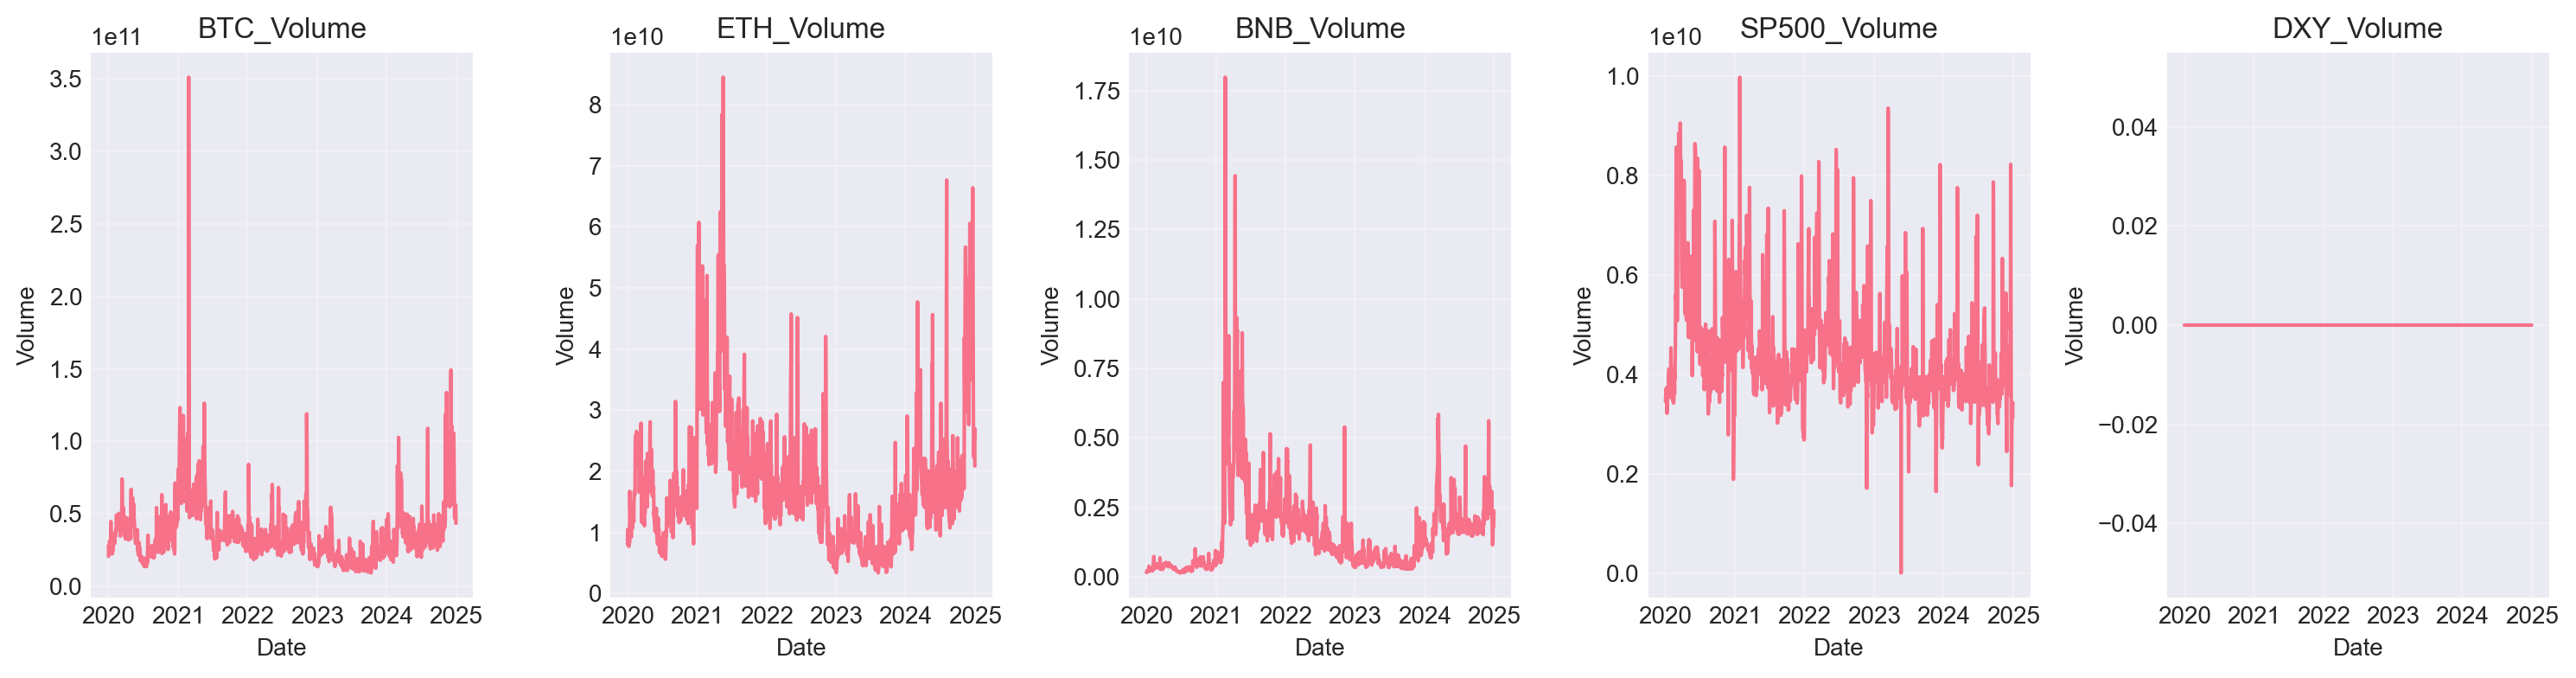

In [38]:
# Volumes
vol_cols = [col for col in df.columns if 'Volume' in col]
if vol_cols:
    fig, axes = plt.subplots(1, len(vol_cols), figsize=(15, 4))
    if len(vol_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(vol_cols):
        axes[i].plot(df.index, df[col])
        axes[i].set_title(col)
        axes[i].set_xlabel('Date')
        axes[i].set_ylabel('Volume')
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 3. Corrélations

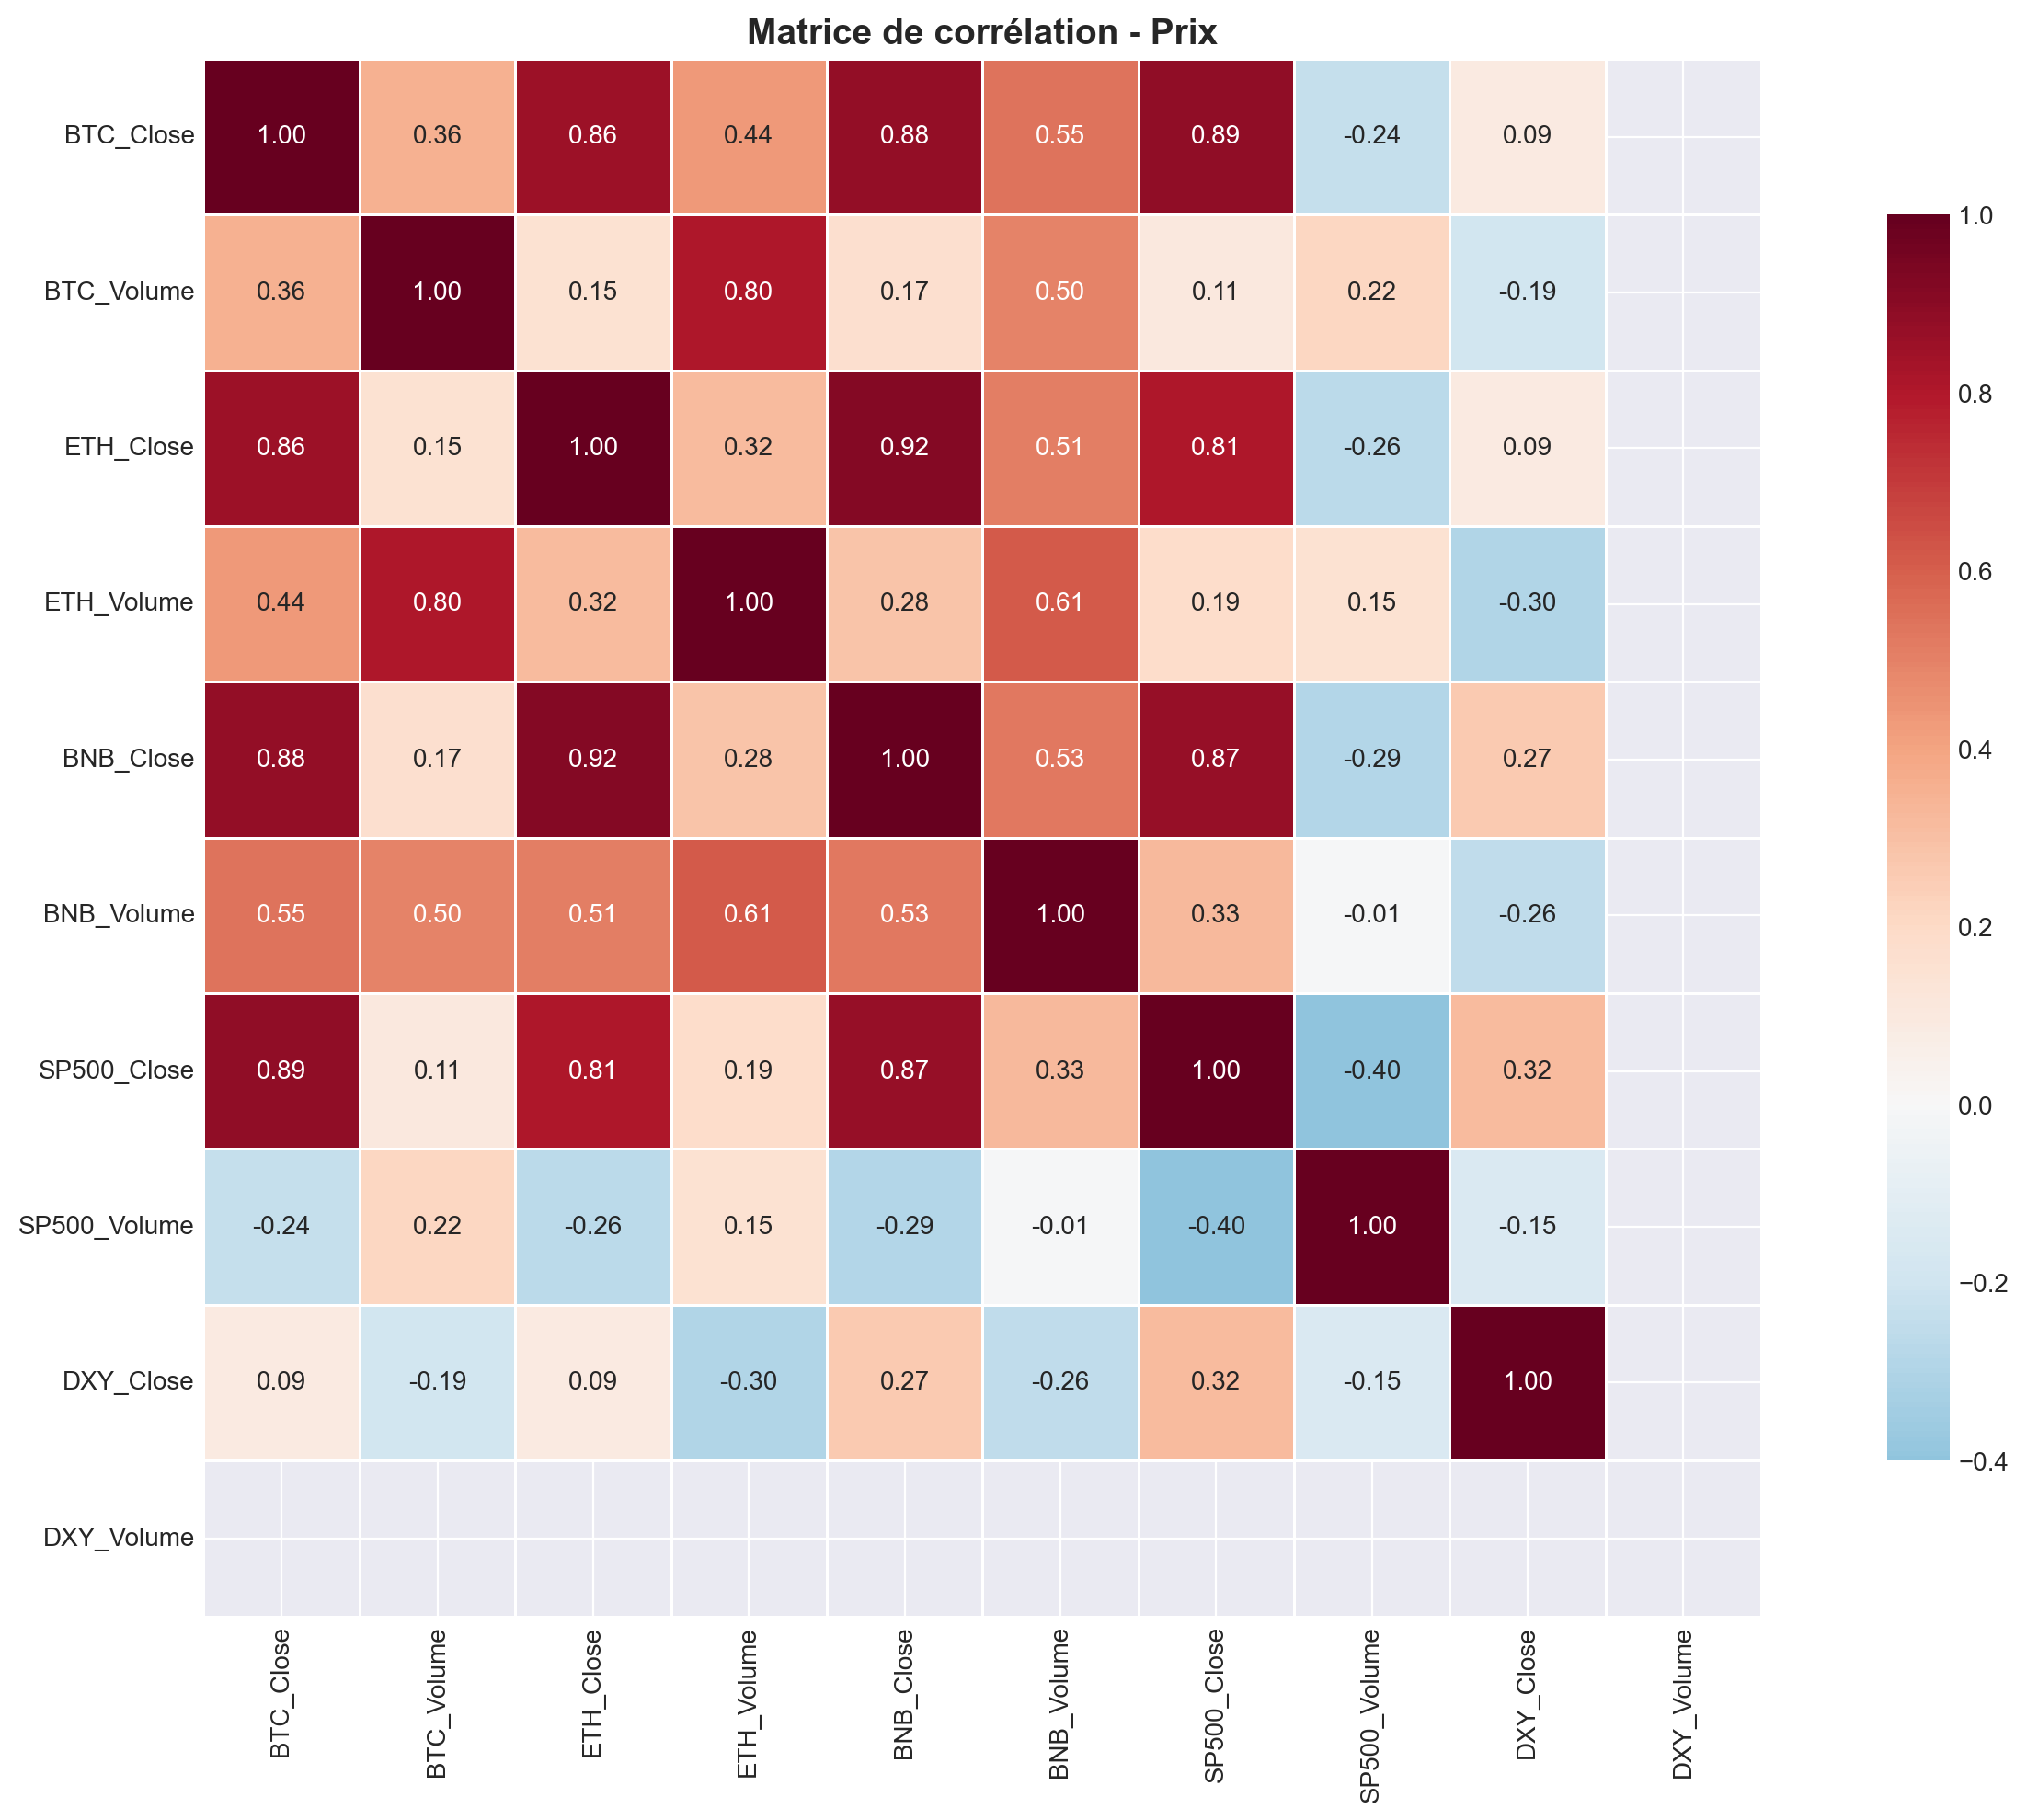

In [39]:
# Matrice de corrélation complète
corr_matrix = viz.plot_correlation_matrix(df, title="Matrice de corrélation - Prix")

In [40]:
# Corrélation avec BTC
btc_corr = corr_matrix['BTC_Close'].sort_values(ascending=False)
print("Corrélations avec BTC_Close:")
print(btc_corr)

Corrélations avec BTC_Close:
BTC_Close       1.0000
SP500_Close     0.8871
BNB_Close       0.8795
ETH_Close       0.8567
BNB_Volume      0.5454
ETH_Volume      0.4361
BTC_Volume      0.3589
DXY_Close       0.0904
SP500_Volume   -0.2406
DXY_Volume         NaN
Name: BTC_Close, dtype: float64


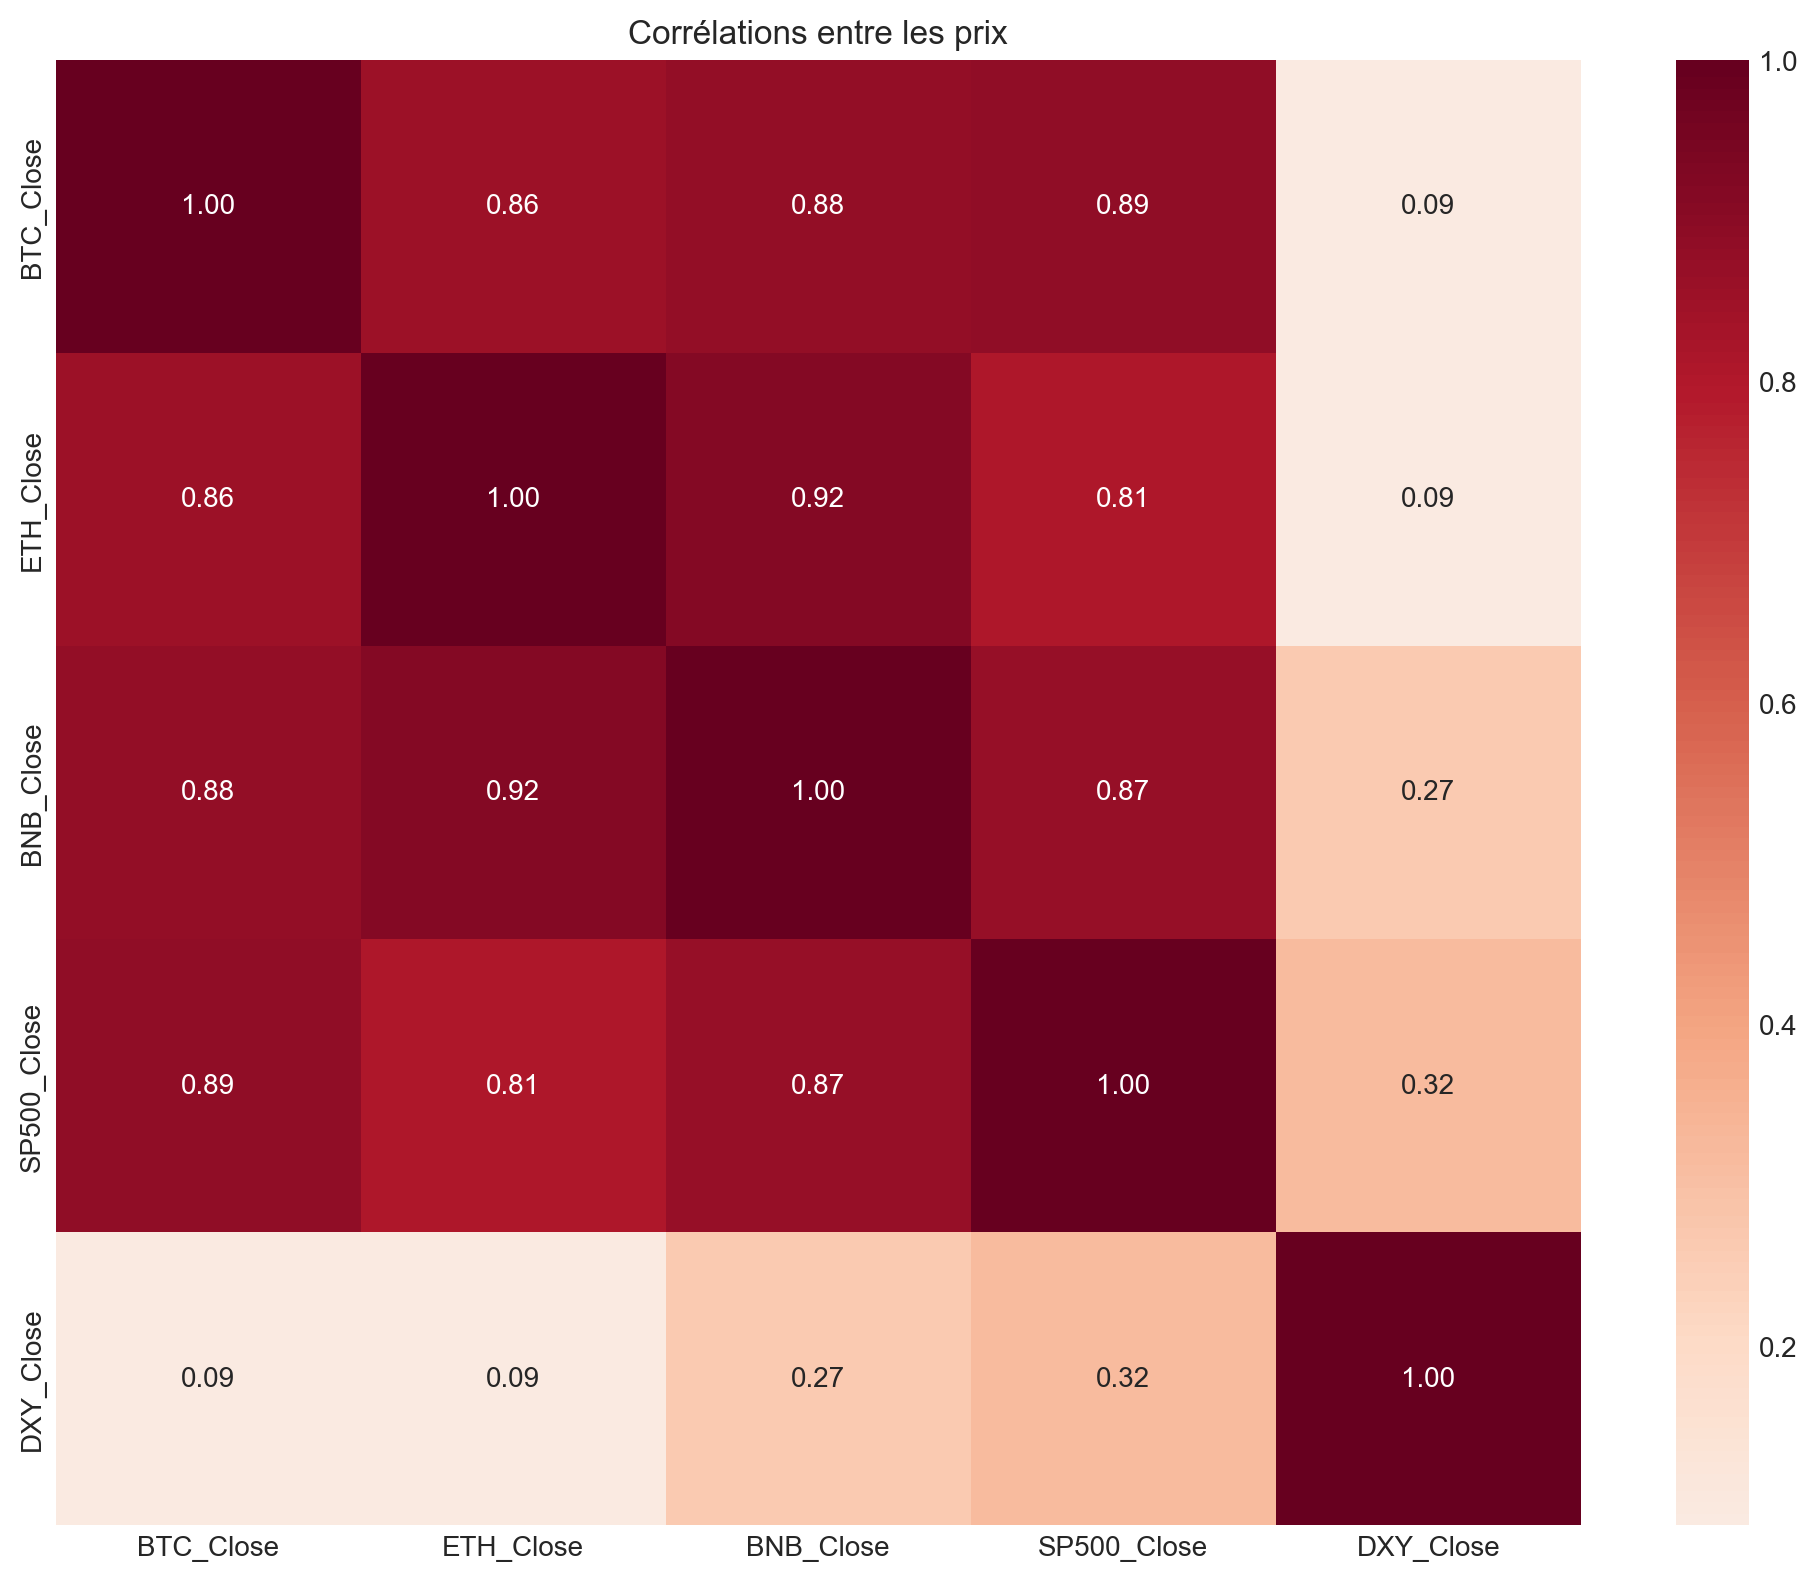

In [41]:
# Heatmap des corrélations croisées
plt.figure(figsize=(10, 8))
sns.heatmap(df[price_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Corrélations entre les prix')
plt.tight_layout()
plt.show()

## 4. Analyse des retours

In [42]:
# Calcul des log-retours
from src.data.features import FeatureEngineer
fe = FeatureEngineer(config_path="../config.yaml")
df_returns = fe.compute_returns(df, log_returns=True)
df_returns.head()

,BTC_Close,BTC_Volume,ETH_Close,ETH_Volume,BNB_Close,BNB_Volume,SP500_Close,SP500_Volume,DXY_Close,DXY_Volume,BTC_Close_log_return,ETH_Close_log_return,BNB_Close_log_return,SP500_Close_log_return,DXY_Close_log_return
Date,,,,,,,,,,,,,,,
2020-01-02,6985.4702,20802083465,127.4102,8032709256,13.0270,156376427,3257.8501,3459930000,96.8500,0,NaN,NaN,NaN,NaN,NaN
2020-01-03,7344.8843,28111481032,134.1717,10476845358,13.6605,173683857,3234.8501,3484700000,96.8400,0,0.0502,0.0517,0.0475,-0.0071,-0.0001
2020-01-06,7769.2192,23276261598,144.3042,9093747121,14.9578,224800409,3246.2800,3702460000,96.6700,0,0.0562,0.0728,0.0907,0.0035,-0.0018
2020-01-07,8163.6924,28767291327,143.5440,9257954672,15.0092,191948560,3237.1799,3435910000,96.9800,0,0.0495,-0.0053,0.0034,-0.0028,0.0032
2020-01-08,8079.8628,31672559265,141.2581,9387194957,14.6029,183632222,3253.0500,3726840000,97.3000,0,-0.0103,-0.0161,-0.0274,0.0049,0.0033


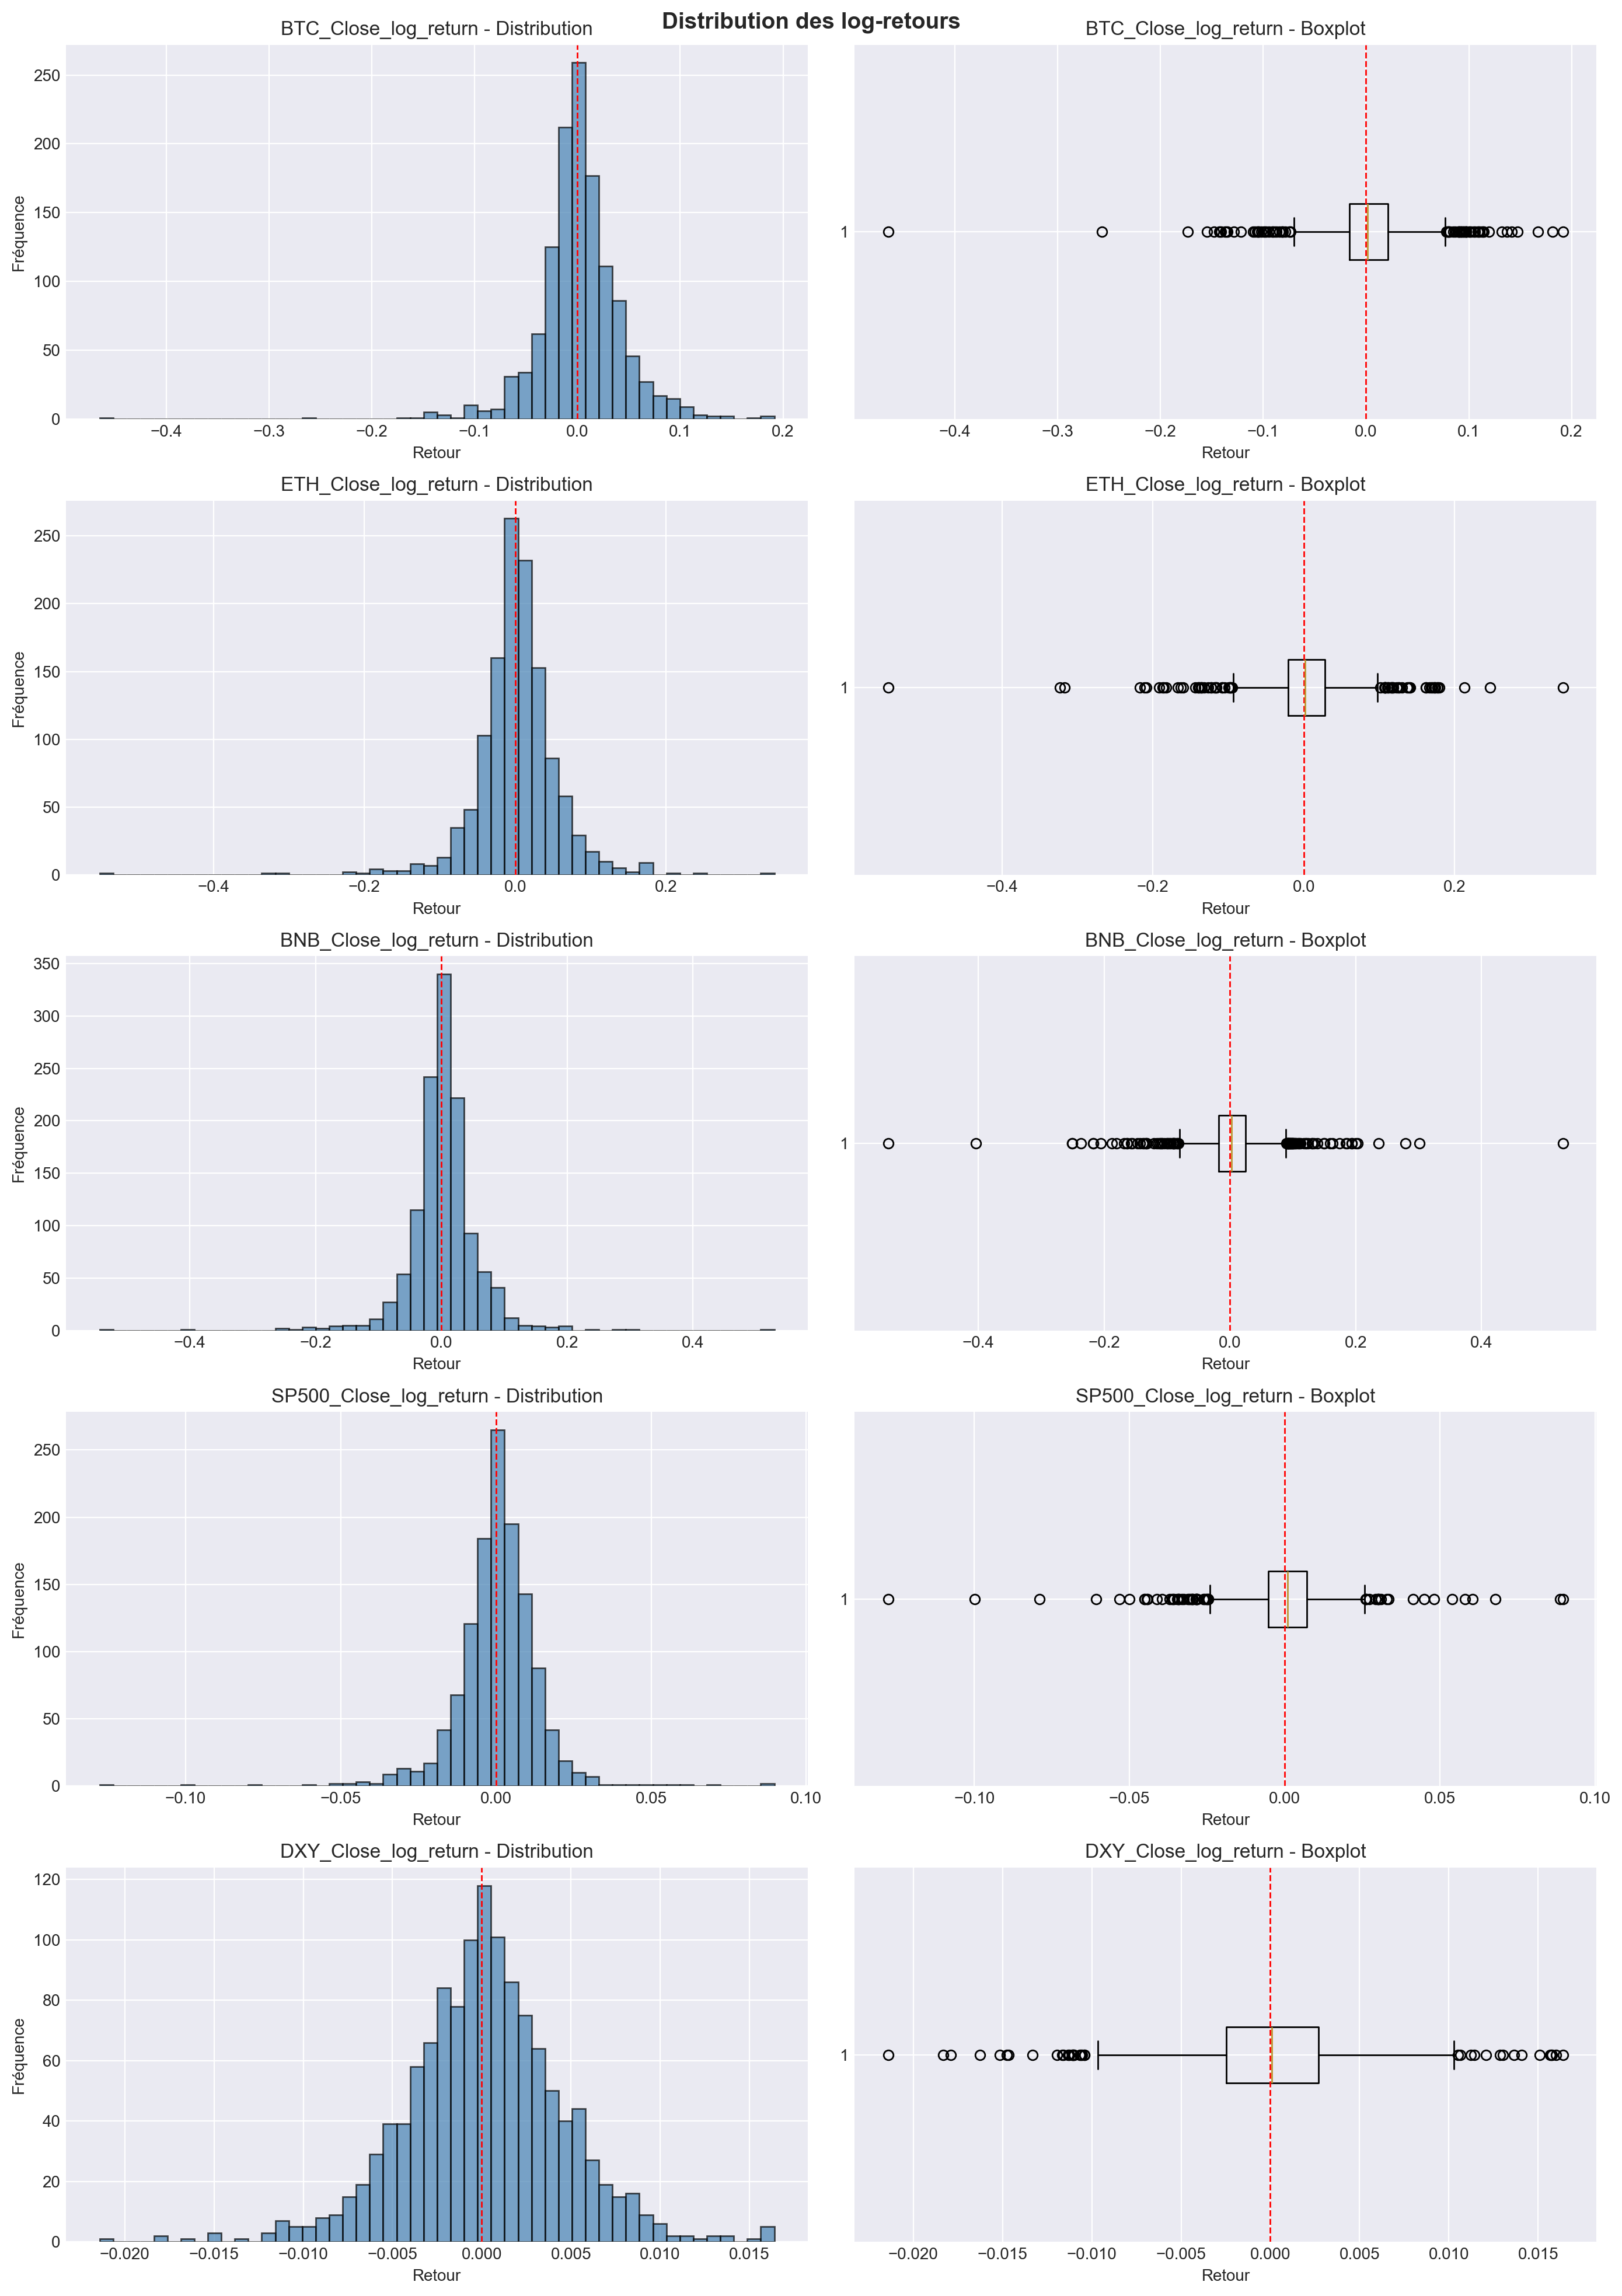

In [43]:
# Distribution des retours
viz.plot_returns_distribution(df_returns, title="Distribution des log-retours")

In [44]:
# Statistiques des retours
return_cols = [col for col in df_returns.columns if 'return' in col]
df_returns[return_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
BTC_Close_log_return,1257.0000,0.0021,0.0415,-0.4647,-0.0161,0.0012,0.0214,0.1915
ETH_Close_log_return,1257.0000,0.0026,0.0541,-0.5507,-0.0209,0.0021,0.0279,0.3435
BNB_Close_log_return,1257.0000,0.0032,0.0554,-0.5431,-0.0176,0.0021,0.0250,0.5292
SP500_Close_log_return,1257.0000,0.0005,0.0135,-0.1277,-0.0053,0.0009,0.0072,0.0897
DXY_Close_log_return,1257.0000,0.0001,0.0044,-0.0214,-0.0025,0.0001,0.0027,0.0164


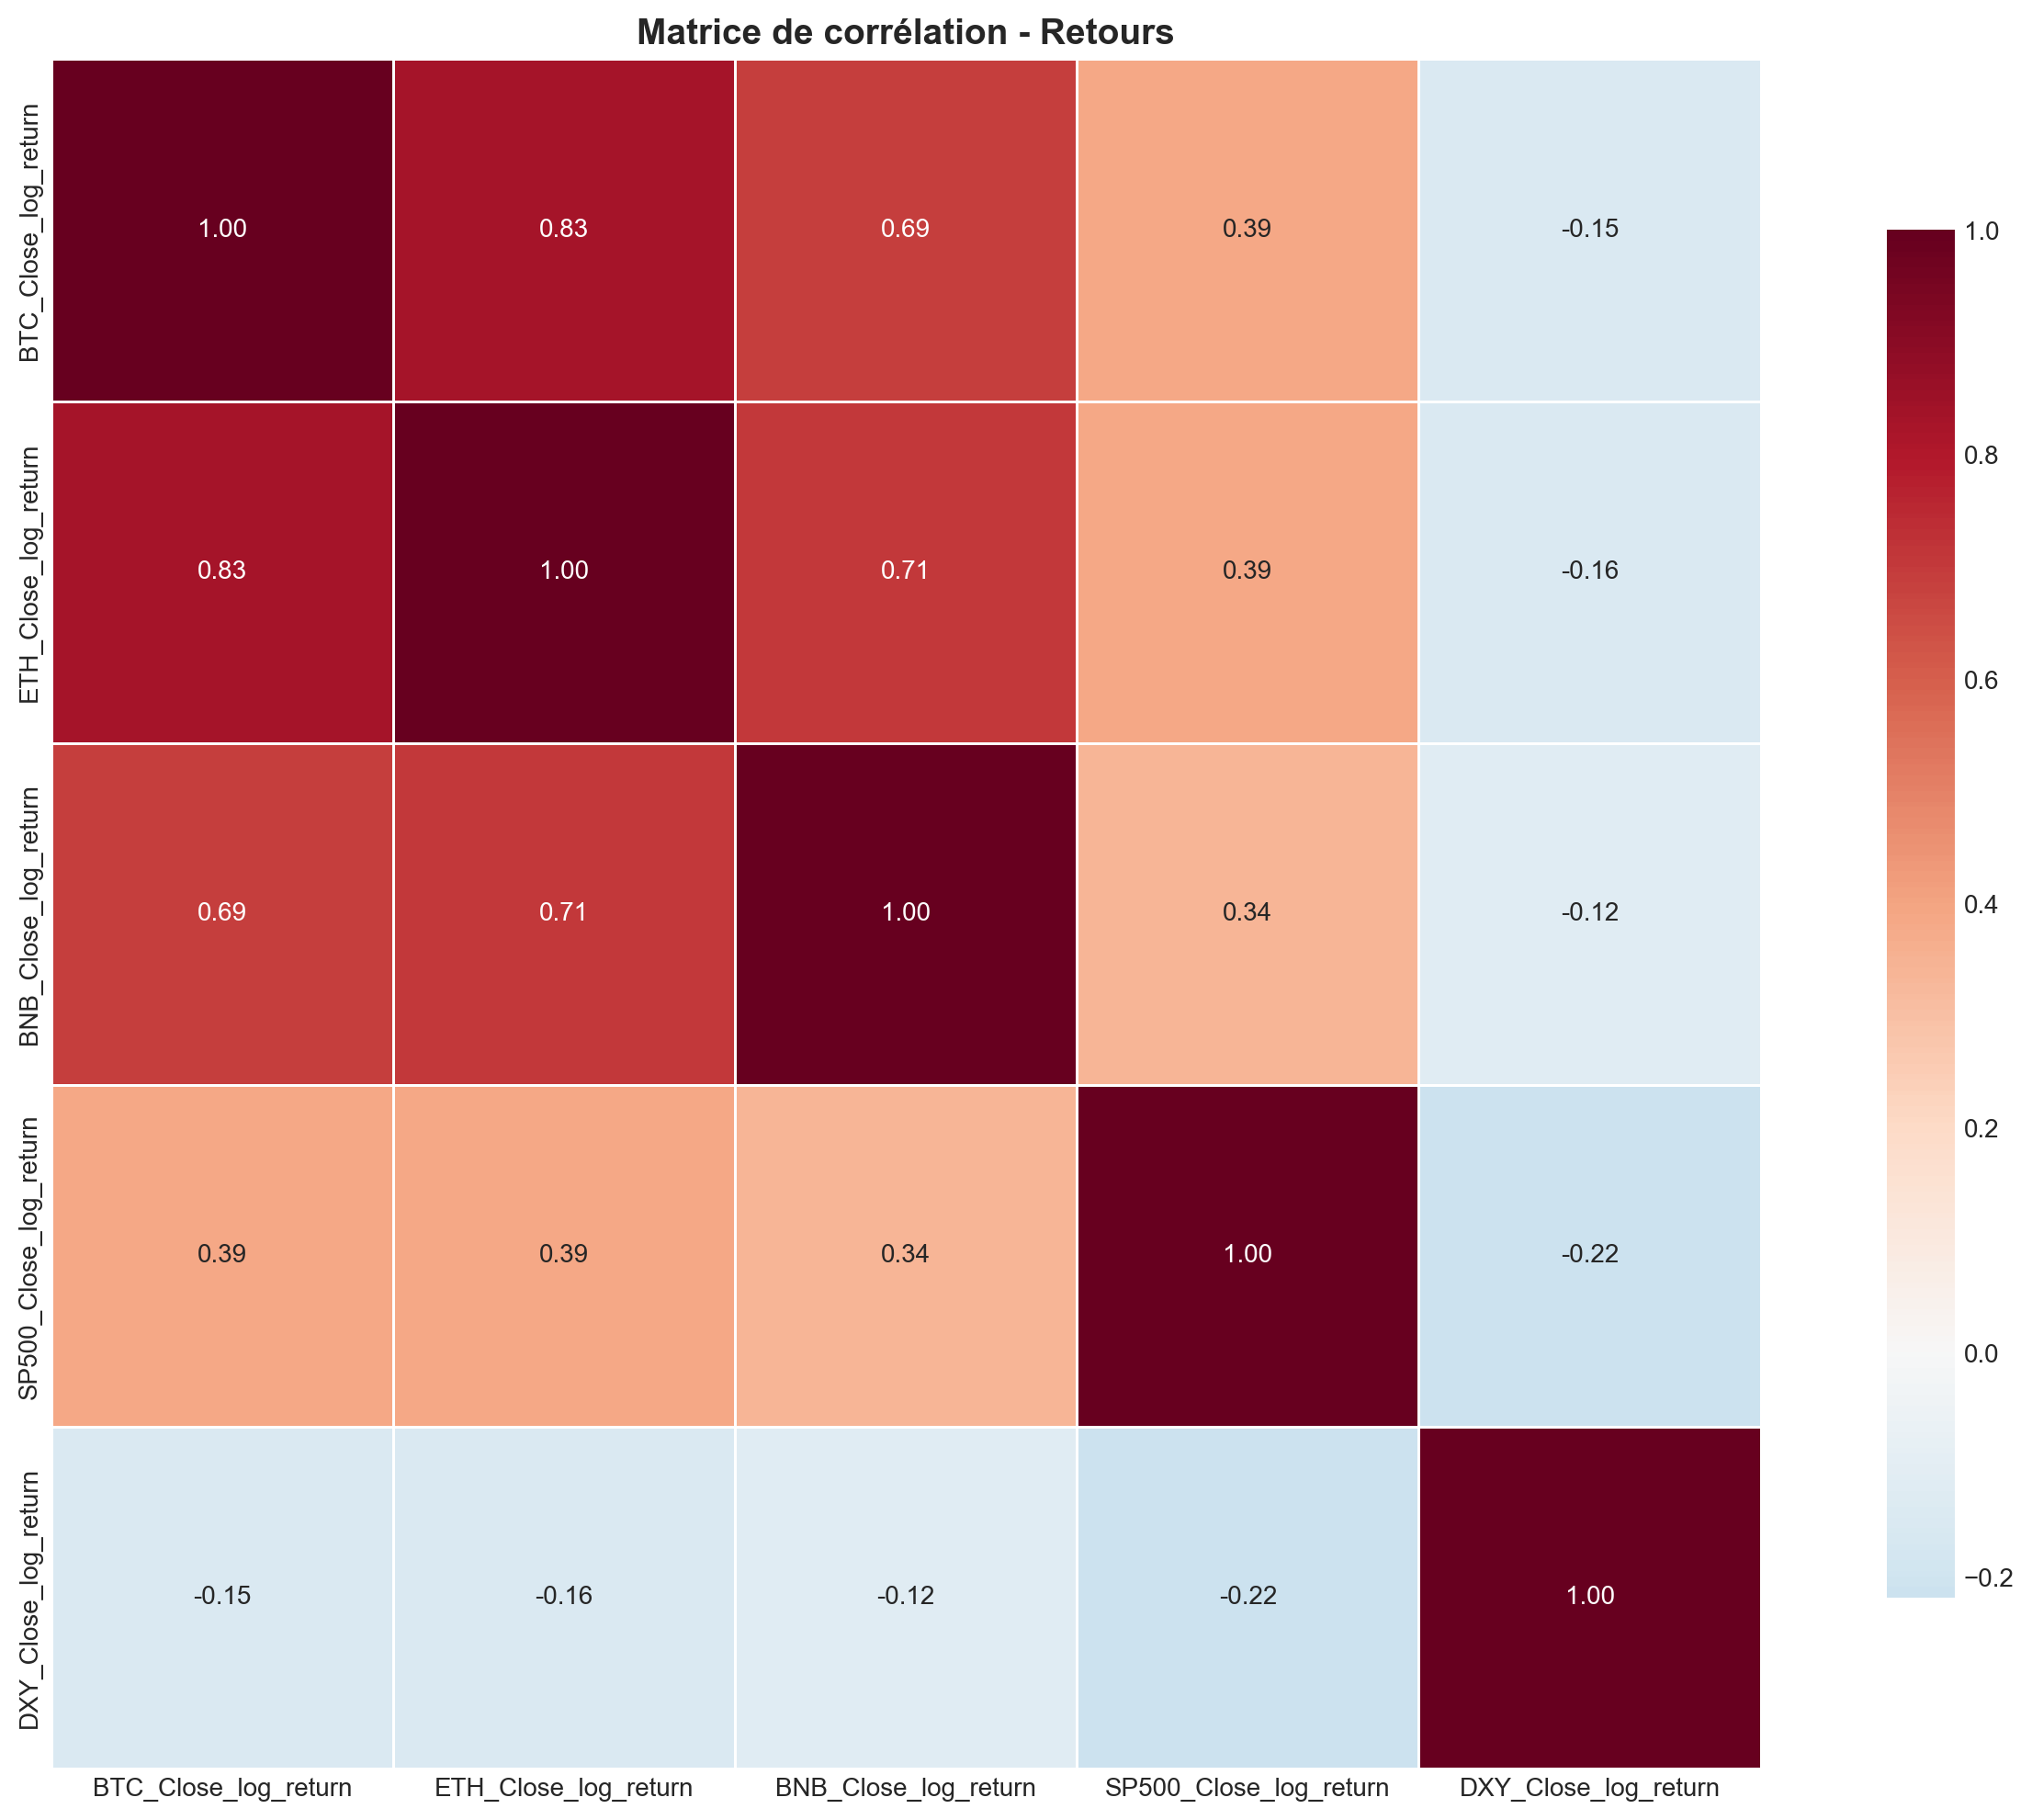

,BTC_Close_log_return,ETH_Close_log_return,BNB_Close_log_return,SP500_Close_log_return,DXY_Close_log_return
BTC_Close_log_return,1.0000,0.8309,0.6893,0.3865,-0.1479
ETH_Close_log_return,0.8309,1.0000,0.7097,0.3910,-0.1560
BNB_Close_log_return,0.6893,0.7097,1.0000,0.3368,-0.1217
SP500_Close_log_return,0.3865,0.3910,0.3368,1.0000,-0.2181
DXY_Close_log_return,-0.1479,-0.1560,-0.1217,-0.2181,1.0000


In [45]:
# Corrélation des retours
viz.plot_correlation_matrix(df_returns[return_cols], 
                          title="Matrice de corrélation - Retours")

## 5. Premières conclusions

### Observations:
- BTC est fortement corrélé avec ETH et BNB
- Corrélation plus faible avec SP500 et DXY
- Les retours suivent une distribution leptokurtique
- Absence de valeurs manquantes après preprocessing

### Recommandations pour Étudiant B:
1. Utiliser ETH et BNB comme variables explicatives principales
2. Tester SP500/DXY comme variables additionnelles
3. Travailler sur les log-retours plutôt que les prix bruts
4. Horizon H=1 jour recommandé pour débuter